# Appendix: Code

In [31]:
library(tidyverse)
library(rstan)
library(bayesplot)

options(mc.cores = parallel::detectCores())
rstan_options(auto_write = TRUE)
theme_set(theme_minimal())

## Load Data and Preprocessing

In [32]:
telco_raw <- read_csv("Telco-Customer-Churn.csv",
                      show_col_types = FALSE)

telco <- telco_raw %>%
  mutate(
    Churn = if_else(Churn == "Yes", 1L, 0L),
    Contract = factor(Contract),
    InternetService = factor(InternetService),
    PaymentMethod = factor(`PaymentMethod`)
  )

glimpse(telco)
unique(telco$Contract)

Rows: 7,043
Columns: 21
$ customerID       <chr> "7590-VHVEG", "5575-GNVDE", "3668-QPYBK", "7795-CFOCW…
$ gender           <chr> "Female", "Male", "Male", "Male", "Female", "Female",…
$ SeniorCitizen    <dbl> 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,…
$ Partner          <chr> "Yes", "No", "No", "No", "No", "No", "No", "No", "Yes…
$ Dependents       <chr> "No", "No", "No", "No", "No", "No", "Yes", "No", "No"…
$ tenure           <dbl> 1, 34, 2, 45, 2, 8, 22, 10, 28, 62, 13, 16, 58, 49, 2…
$ PhoneService     <chr> "No", "Yes", "Yes", "No", "Yes", "Yes", "Yes", "No", …
$ MultipleLines    <chr> "No phone service", "No", "No", "No phone service", "…
$ InternetService  <fct> DSL, DSL, DSL, DSL, Fiber optic, Fiber optic, Fiber o…
$ OnlineSecurity   <chr> "No", "Yes", "Yes", "Yes", "No", "No", "No", "Yes", "…
$ OnlineBackup     <chr> "Yes", "No", "Yes", "No", "No", "No", "Yes", "No", "N…
$ DeviceProtection <chr> "No", "Yes", "No", "Yes", "No", "Yes", "No", "No", "Y…
$ TechSupport   

[1] Month-to-month One year       Two year      
Levels: Month-to-month One year Two year

## Exploratory Data Visualization

Saving 6.67 x 6.67 in image


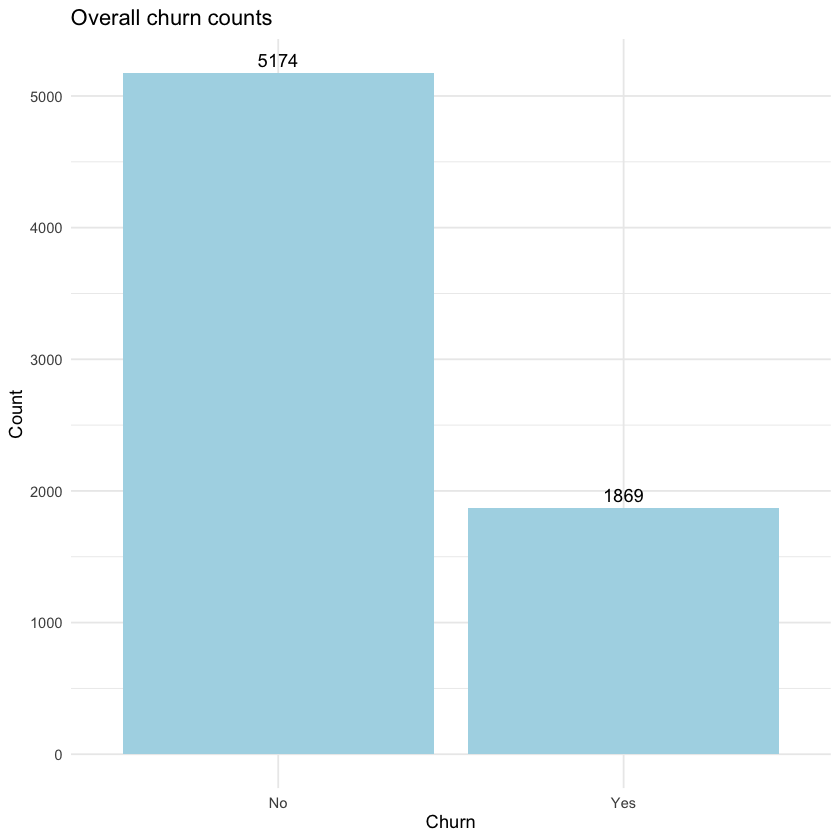

In [33]:
# Overall churn vs non-churn counts
plot_churn_bar <- telco %>%
  count(Churn) %>%
  mutate(Churn = factor(Churn, levels = c(0, 1),
                        labels = c("No", "Yes"))) %>%
  ggplot(aes(x = Churn, y = n)) +
  geom_col(fill = "lightblue") +
  geom_text(aes(label = n), vjust = -0.5) +
  labs(title = "Overall churn counts",
       x = "Churn", y = "Count")

plot_churn_bar
ggsave("churn_bar.png", plot_churn_bar, dpi = 300)

Saving 6.67 x 6.67 in image


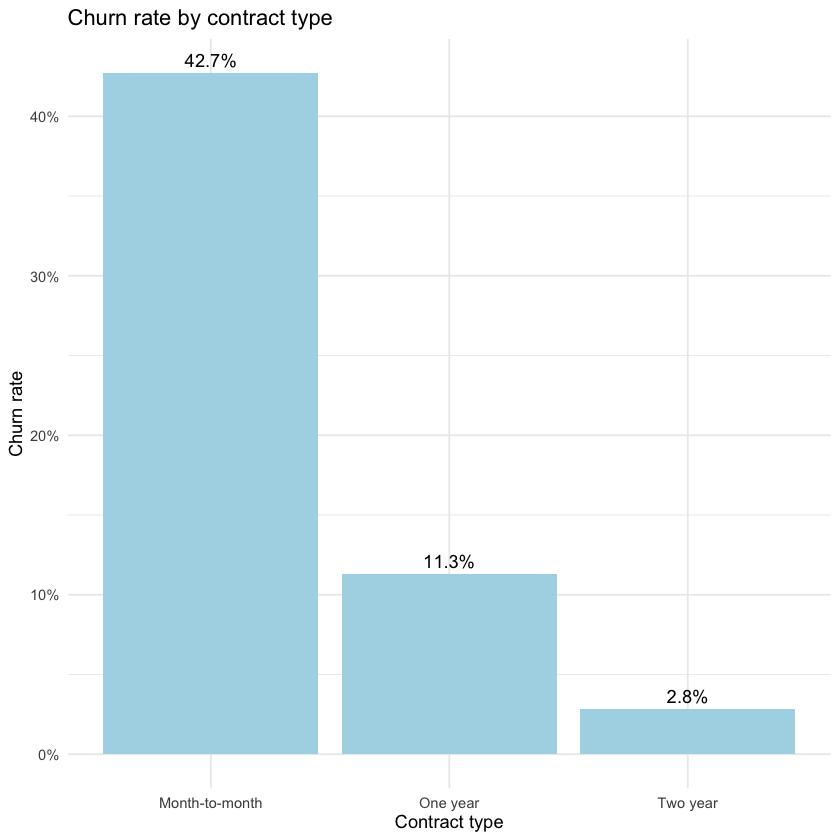

In [34]:
# Churn rate by Contract type
churn_by_contract <- telco %>%
  group_by(Contract) %>%
  summarise(
    churn_rate = mean(Churn),
    n = n(),
    .groups = "drop"
  )

plot_contract_rate <- churn_by_contract %>%
  ggplot(aes(x = Contract, y = churn_rate)) +
  geom_col(fill = "lightblue") +
  geom_text(aes(label = scales::percent(churn_rate, accuracy = 0.1)),
            vjust = -0.5) +
  labs(title = "Churn rate by contract type",
       x = "Contract type", y = "Churn rate") +
  scale_y_continuous(labels = scales::percent_format())

plot_contract_rate
ggsave("contract_rate.png", plot_contract_rate, dpi = 300)

## One-parameter Bayesian model: Beta-Binomial

In [35]:
n <- nrow(telco)
y <- sum(telco$Churn)

cat("Sample size:", n, "\nNumber of churns:", y, "\nOverall churn rate:", y / n)

Sample size: 7043 
Number of churns: 1869 
Overall churn rate: 0.2653699

In [36]:
set.seed(321)
a <- 1; b <- 1

post_a <- a + y
post_b <- b + (n - y)

post_mean <- post_a / (post_a + post_b)
ci <- qbeta(c(0.025, 0.975), post_a, post_b)

cat("Posterior mean:", post_mean)
cat("\n95% Confidence Interval: [", ci[1], ", ", ci[2], "]")

Posterior mean: 0.2654365
95% Confidence Interval: [ 0.2551897 ,  0.2758094 ]

Saving 6.67 x 6.67 in image


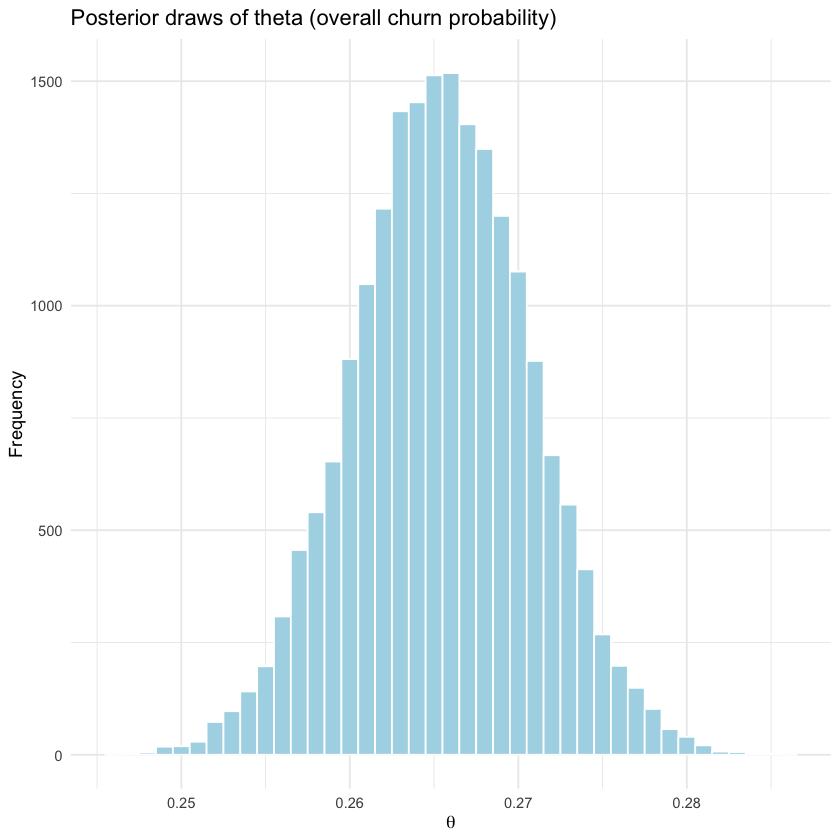

In [37]:
# Monte Carlo approximation from posterior Beta
set.seed(321)
n_sims <- 20000
theta_samples <- rbeta(n_sims, post_a, post_b)
theta_df <- data.frame(theta = theta_samples)

ggplot(theta_df, aes(x = theta)) +
  geom_histogram(binwidth = 0.001, fill = "lightblue", color = "white") +
  labs(
    title = "Posterior draws of theta (overall churn probability)",
    x = expression(theta),
    y = "Frequency"
  ) +
  theme_minimal()
ggsave("mc_posterior.png", dpi = 300)

Posterior predictive p-value: 1.0005

Saving 6.67 x 6.67 in image


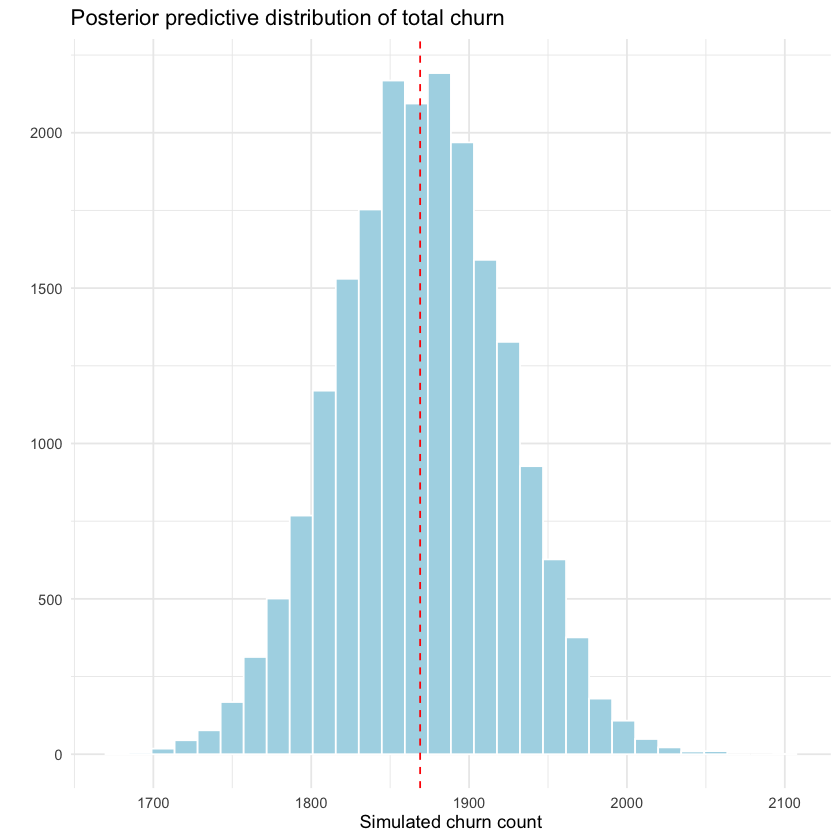

In [38]:
# Posterior predictive distribution for churn count (overall)
set.seed(321)
y_rep_total <- rbinom(n_sims, size = n, prob = theta_samples)

ppc_total_hist <- qplot(y_rep_total,
                        bins = 30,
                        xlab = "Simulated churn count",
                        main = "Posterior predictive distribution of total churn",
                        fill = I("lightblue"), color = I("white")) +
  geom_vline(xintercept = y, color = "red", linetype = "dashed") +
  theme_minimal()

ppc_total_hist

pp_value_total <- 2 * min(
  mean(y_rep_total <= y),
  mean(y_rep_total >= y)
)
cat("Posterior predictive p-value:", pp_value_total)
ggsave("ppc_total.png", ppc_total_hist, dpi = 300)

## Hierarchical Beta-Binomial model by Contract

In [39]:
group_data <- telco %>%
  group_by(Contract) %>%
  summarise(
    n = n(),
    y = sum(Churn),
    .groups = "drop"
  )

group_data

J <- nrow(group_data)
n_j <- group_data$n
y_j <- group_data$y

stan_data_hier <- list(
  J = J,
  n = n_j,
  y = y_j
)

Contract,n,y
<fct>,<int>,<int>
Month-to-month,3875,1655
One year,1473,166
Two year,1695,48


In [40]:
set.seed(321)

fit_hier <- stan(
  file = "hierarchical_model.stan",
  data = stan_data_hier,
  iter = 2000,
  warmup = 1000,
  chains = 4,
  seed = 321
)
fit_hier

Inference for Stan model: anon_model.
4 chains, each with iter=2000; warmup=1000; thin=1; 
post-warmup draws per chain=1000, total post-warmup draws=4000.

             mean se_mean    sd     2.5%      25%      50%      75%    97.5%
alpha        0.63    0.01  0.35     0.15     0.38     0.57     0.81     1.49
beta         1.80    0.02  1.11     0.33     0.98     1.58     2.36     4.60
theta[1]     0.43    0.00  0.01     0.41     0.42     0.43     0.43     0.44
theta[2]     0.11    0.00  0.01     0.10     0.11     0.11     0.12     0.13
theta[3]     0.03    0.00  0.00     0.02     0.03     0.03     0.03     0.04
y_rep[1]  1655.03    0.67 43.08  1570.00  1627.00  1654.00  1684.00  1742.00
y_rep[2]   166.73    0.25 17.33   134.00   155.00   166.00   178.00   201.00
y_rep[3]    48.81    0.14  9.92    31.00    42.00    48.50    55.00    70.00
lp__     -3392.08    0.04  1.59 -3396.04 -3392.94 -3391.78 -3390.91 -3389.96
         n_eff Rhat
alpha     4179    1
beta      4293    1
theta[1]  4924

## Hierarchical model: visualizing posterior $\theta_j$

Saving 6.67 x 6.67 in image


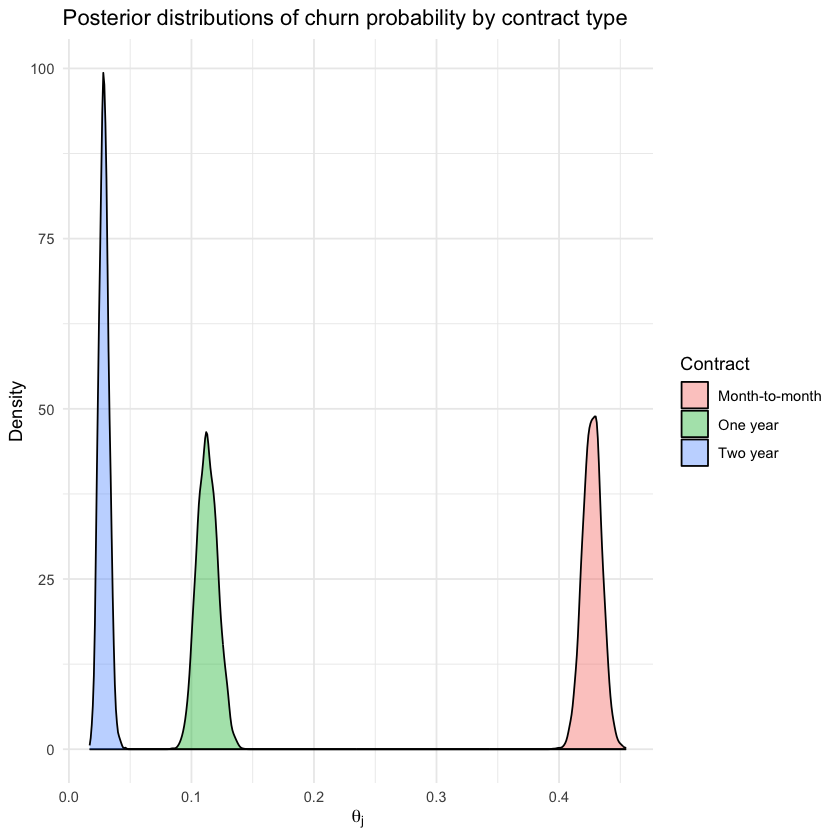

In [41]:
set.seed(321)
posterior_draws <- rstan::extract(fit_hier)

theta_draws <- posterior_draws$theta
alpha_draws <- posterior_draws$alpha
beta_draws  <- posterior_draws$beta

theta_df <- as_tibble(theta_draws) %>%
  setNames(as.character(group_data$Contract)) %>%
  pivot_longer(cols = everything(),
               names_to = "Contract",
               values_to = "theta")

# Density plots for each contract type
plot_theta_contract_density <- theta_df %>%
  ggplot(aes(x = theta, fill = Contract)) +
  geom_density(alpha = 0.4) +
  labs(title = "Posterior distributions of churn probability by contract type",
       x = expression(theta[j]),
       y = "Density")

plot_theta_contract_density
ggsave("theta_density.png", plot_theta_contract_density, dpi = 300)

Contract,mean,lower,upper
<chr>,<dbl>,<dbl>,<dbl>
Month-to-month,0.42704493,0.41196484,0.44209521
One year,0.11300355,0.09735568,0.12982998
Two year,0.02864402,0.02136632,0.03678006


Saving 6.67 x 6.67 in image


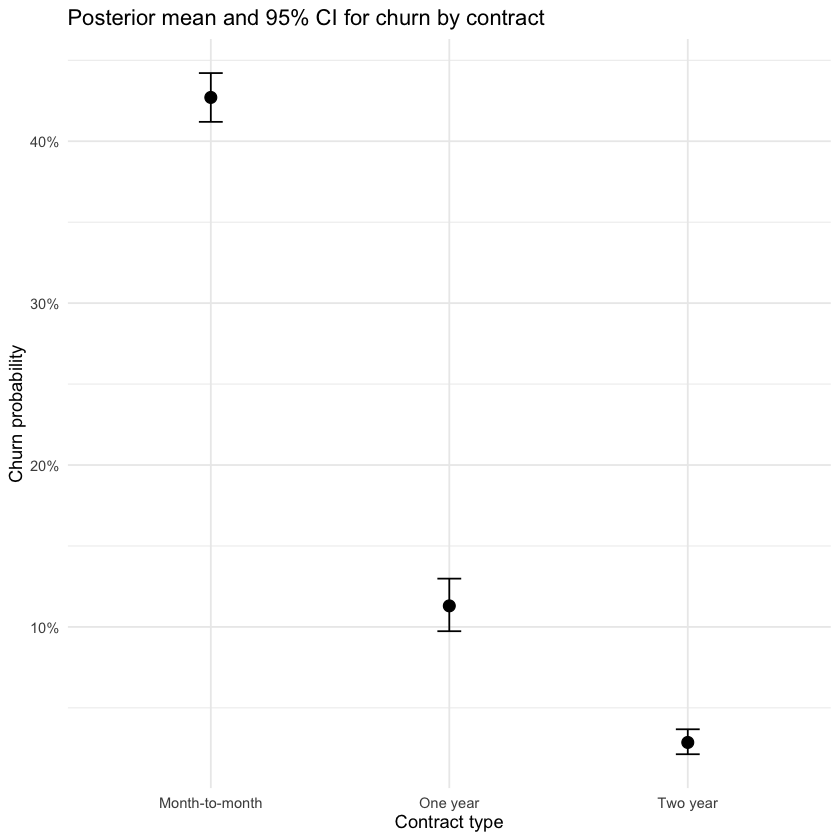

In [42]:
# Posterior means & 95% intervals for theta_j
theta_summary <- theta_df %>%
  group_by(Contract) %>%
  summarise(
    mean = mean(theta),
    lower = quantile(theta, 0.025),
    upper = quantile(theta, 0.975),
    .groups = "drop"
  )

theta_summary

plot_theta_contract_interval <- theta_summary %>%
  ggplot(aes(x = Contract, y = mean)) +
  geom_point(size = 3) +
  geom_errorbar(aes(ymin = lower, ymax = upper),
                width = 0.1) +
  labs(title = "Posterior mean and 95% CI for churn by contract",
       x = "Contract type",
       y = "Churn probability") +
  scale_y_continuous(labels = scales::percent_format())

plot_theta_contract_interval
ggsave("theta_interval.png", plot_theta_contract_interval, dpi = 300)

## Group-level posterior predictive check

Saving 6.67 x 6.67 in image


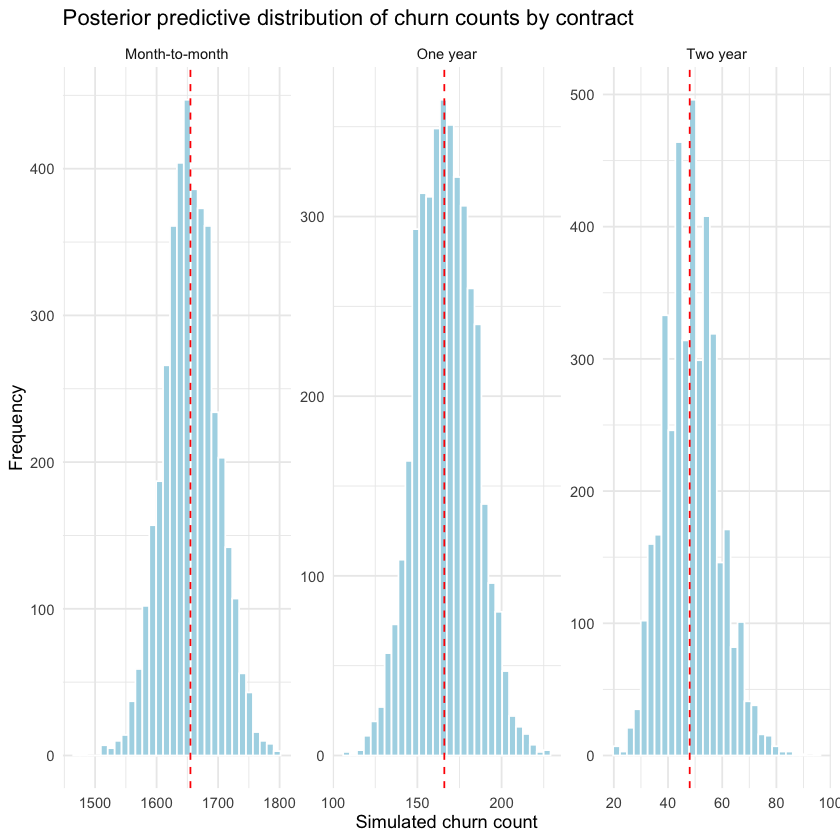

In [43]:
yrep_mat <- posterior_draws$y_rep

yrep_df <- as_tibble(yrep_mat) %>%
  setNames(as.character(group_data$Contract)) %>%
  pivot_longer(cols = everything(),
               names_to = "Contract",
               values_to = "y_rep")

obs_df <- group_data %>%
  select(Contract, y) %>%
  mutate(Contract = as.character(Contract))

ppc_contract <- yrep_df %>%
  ggplot(aes(x = y_rep)) +
  geom_histogram(bins = 30, fill = "lightblue", color = "white") +
  facet_wrap(~ Contract, scales = "free") +
  geom_vline(data = obs_df,
             aes(xintercept = y),
             color = "red", linetype = "dashed") +
  labs(title = "Posterior predictive distribution of churn counts by contract",
       x = "Simulated churn count",
       y = "Frequency")

ppc_contract
ggsave("ppc_contract.png", ppc_contract, dpi = 300)

In [44]:
# Compute simple PPC p-values per group
pp_contract_p <- yrep_df %>%
  group_by(Contract) %>%
  summarise(
    p_lower = mean(y_rep <= obs_df$y[match(Contract, obs_df$Contract)]),
    p_upper = mean(y_rep >= obs_df$y[match(Contract, obs_df$Contract)]),
    .groups = "drop"
  ) %>%
  mutate(p_two_sided = 2 * pmin(p_lower, p_upper))

pp_contract_p

Contract,p_lower,p_upper,p_two_sided
<chr>,<dbl>,<dbl>,<dbl>
Month-to-month,0.51450,0.4960,0.9920
One year,0.50475,0.5175,1.0095
Two year,0.50000,0.5370,1.0000


## Compare one-parameter vs hierarchical at group level

Contract,n,y,expected_y_oneparam
<fct>,<int>,<int>,<dbl>
Month-to-month,3875,1655,1028.5664
One year,1473,166,390.9879
Two year,1695,48,449.9148


Saving 6.67 x 6.67 in image


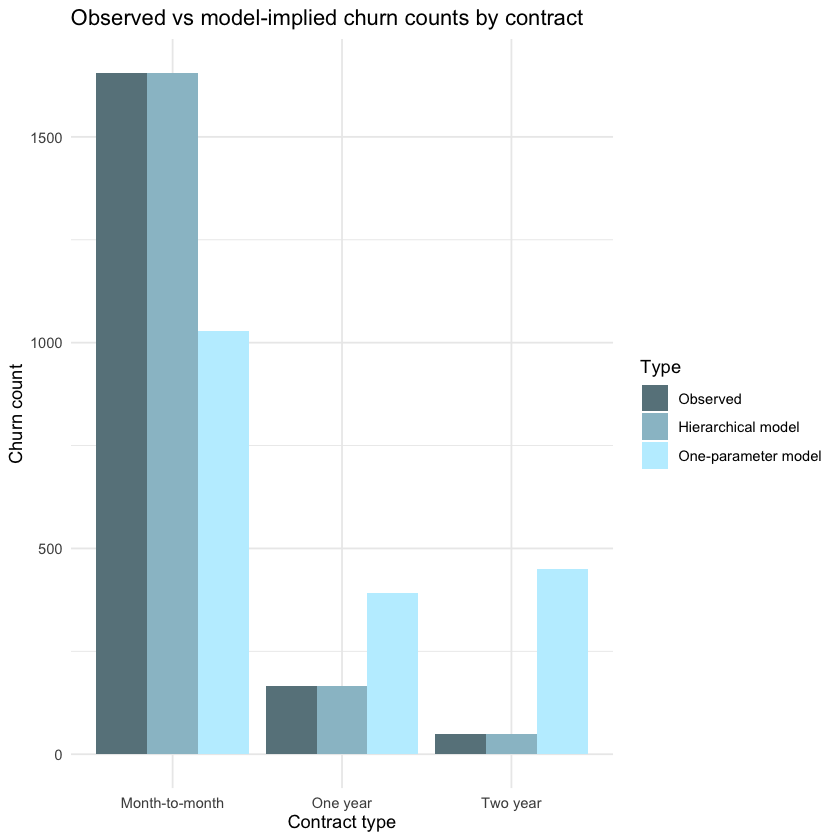

In [45]:
# One-parameter posterior mean theta (from Model 1)
theta_overall_hat <- post_mean

# Expected churn per group under Model 1 (no group structure)
group_data <- group_data %>%
  mutate(
    expected_y_oneparam = n * theta_overall_hat
  )

group_data

plot_compare_models <- group_data %>%
  left_join(theta_summary, by = "Contract") %>%
  mutate(
    expected_y_hier = n * mean
  ) %>%
  pivot_longer(cols = c(expected_y_oneparam, expected_y_hier, y),
               names_to = "type",
               values_to = "value") %>%
  mutate(type = factor(type,
                       levels = c("y",
                                  "expected_y_hier",
                                  "expected_y_oneparam"),
                       labels = c("Observed",
                                  "Hierarchical model",
                                  "One-parameter model"))) %>%
  ggplot(aes(x = Contract, y = value, fill = type)) +
  geom_col(position = "dodge") +
  labs(title = "Observed vs model-implied churn counts by contract",
       x = "Contract type",
       y = "Churn count",
       fill = "Type") +
  scale_fill_manual(
    values = c(
      "Observed" = "lightblue4",
      "Hierarchical model" = "lightblue3",
      "One-parameter model" = "lightblue1"
    )
  ) +
  theme_minimal()

plot_compare_models
ggsave("conparison_models.png", plot_compare_models, dpi = 300)